In [1]:
import pandas as pd
data = pd.read_csv("2026-04-20 12_42pm_2026-05-12-1544.csv")

In [2]:
mask = (
    data['FNL_DRG_CD'].isin([788, 806, 807]) & 
    (data['LOB_CD'] == 'MCM006') & 
    (data['SRVCAREA_ST_SHRT_DESC'] == 'CA') & 
    (data['ANLYTC_INCRD_YEAR_MNTH_NBR'].between(202501, 202512)) & 
    (data['BILLD_CHRG_AMT'] > 0)
)
# SNAP_YEAR_MNTH_NBR == '202604'
df = data[mask]

In [3]:
df.columns

Index(['LOB_PARTN_ID', 'LOB_CD', 'LOB_SHRT_DESC', 'MBU_CF_CD',
       'SRVCAREA_ST_SHRT_DESC', 'ST_NM', 'HCC_CMRCL_MNGMNT_HIGH_SHRT_DESC',
       'HCC_CMRCL_MNGMNT_MEDM_SHRT_DESC', 'HCC_CMRCL_MNGMNT_LOW_SHRT_DESC',
       'SNAP_YEAR_MNTH_NBR', 'ANLYTC_INCRD_YEAR_MNTH_NBR',
       'RNDRG_EDM_PROV_ACCT_KEY', 'PROV_ID', 'RNDRG_PROV_NM',
       'RNDRG_HOSP_SYS_NM', 'FCLTY_TYPE', 'FNL_DRG_CD', 'FNL_DRG_NM',
       'FNL_EDM_DRG_KEY', 'PROC_CD', 'PROC_SHRT_NM', 'PROD_CD',
       'PROD_SHRT_DESC', 'PRMRY_DSCHRG_DIAG_CD', 'PRMRY_DSCHRG_DIAG_NM',
       'PA_RQRD_CD', 'CLM_NBR', 'EDM_AUTHRZN_KEY', 'INN_IND', 'DRG_WT_NBR',
       'ADMIT_CNT', 'ANLYTC_PAID_AMT', 'ANLYTC_ALWD_AMT', 'BILLD_CHRG_AMT',
       'ANLYTC_CLM_ADMT_KEY', 'ER_ADMT_IND'],
      dtype='object')

In [4]:
imp = ['LOB_CD', 'MBU_CF_CD',
       'SRVCAREA_ST_SHRT_DESC',
       'SNAP_YEAR_MNTH_NBR', 'ANLYTC_INCRD_YEAR_MNTH_NBR', 'PROV_ID', 'RNDRG_PROV_NM',
       'RNDRG_HOSP_SYS_NM', 'FCLTY_TYPE', 'FNL_DRG_CD', 'FNL_DRG_NM',
       'FNL_EDM_DRG_KEY', 'PROC_CD', 'PROC_SHRT_NM', 'PROD_CD', 'PRMRY_DSCHRG_DIAG_CD', 'CLM_NBR', 'EDM_AUTHRZN_KEY', 'INN_IND', 'DRG_WT_NBR',
       'ADMIT_CNT', 'ANLYTC_PAID_AMT', 'ANLYTC_ALWD_AMT', 'BILLD_CHRG_AMT', 'ER_ADMT_IND']

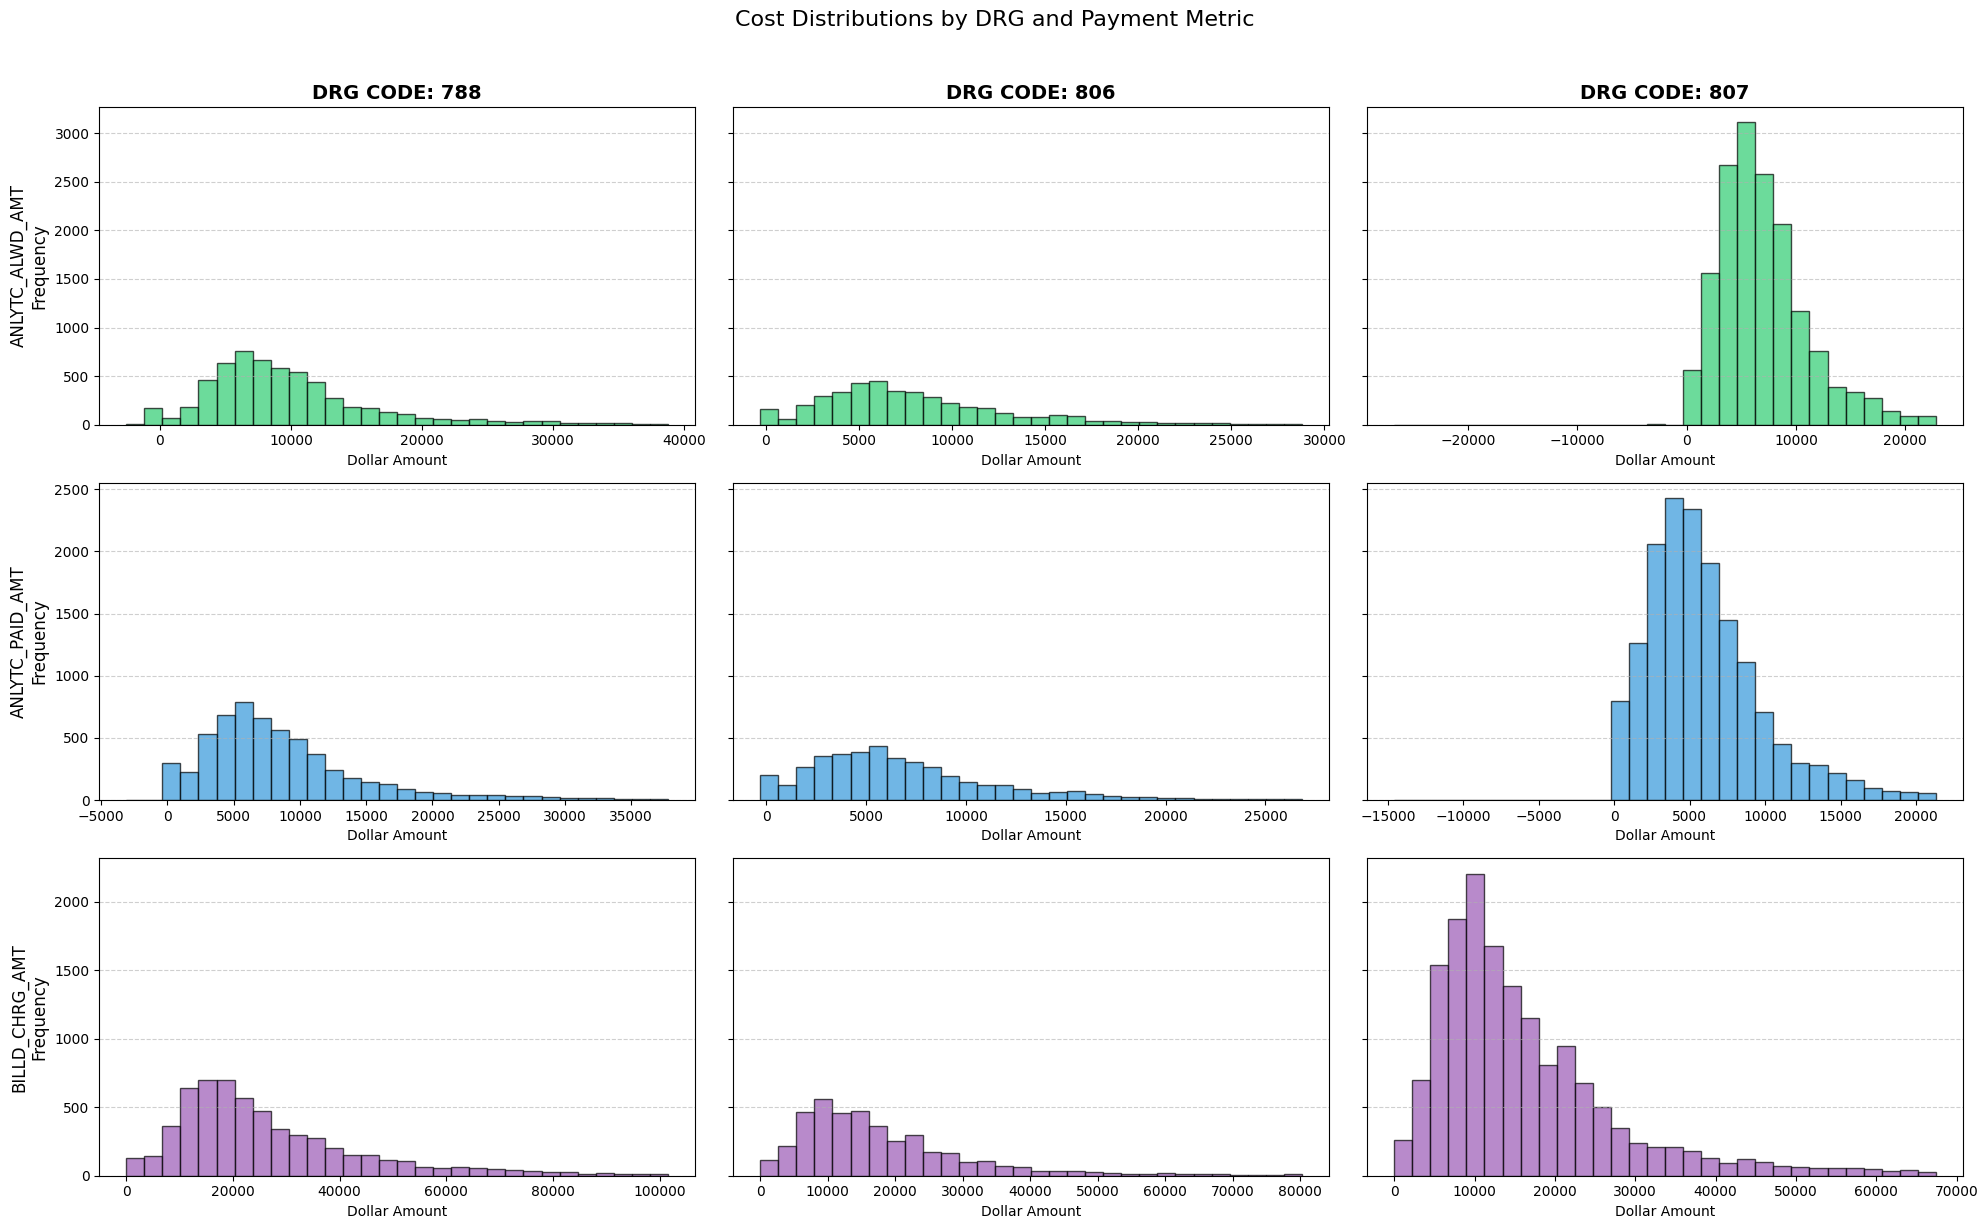

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the DRGs and the columns to plot
drg_codes = [788, 806, 807]
metrics = ['ANLYTC_ALWD_AMT', 'ANLYTC_PAID_AMT', 'BILLD_CHRG_AMT']
colors = ['#2ecc71', '#3498db', '#9b59b6'] # Green, Blue, Purple

# 2. Setup the figure (Rows = Metrics, Cols = DRGs)
fig, axes = plt.subplots(len(metrics), len(drg_codes), figsize=(20, 12), sharey='row')

for row_idx, metric in enumerate(metrics):
    for col_idx, code in enumerate(drg_codes):
        # Filter for the specific DRG
        subset = df[df['FNL_DRG_CD'] == code][metric]
        
        # Optional: Remove extreme outliers for better visualization (99th percentile)
        upper_limit = subset.quantile(0.99)
        plot_data = subset[subset <= upper_limit]
        
        ax = axes[row_idx, col_idx]
        
        # Plot histogram
        ax.hist(plot_data, bins=30, color=colors[row_idx], edgecolor='black', alpha=0.7)
        
        # Labels and Titles
        if row_idx == 0:
            ax.set_title(f'DRG CODE: {code}', fontsize=14, fontweight='bold')
        
        if col_idx == 0:
            ax.set_ylabel(f'{metric}\nFrequency', fontsize=12)
            
        ax.set_xlabel('Dollar Amount')
        ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Cost Distributions by DRG and Payment Metric', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [45]:

for cd in [788, 806, 807]:
    df2 = df[df['FNL_DRG_CD'] == cd]
    top_prov_ids = df2['PROV_ID'].value_counts().head(10).index.tolist()
    print(cd, ':', top_prov_ids)

788 : ['050224', '050625', '050438', '050069', '050761', '050351', '050549', '050057', '050678', '050290']
806 : ['050224', '050025', '050625', '050396', '050492', '050039', '00540W', '050603', '050231', '050112']
807 : ['050224', '050625', '050025', '050069', '050603', '050549', '050351', '00540W', '050678', '053309']


In [1]:
# 1. Identify the top 5 providers
df2 = df[df['FNL_DRG_CD']==807]
top_prov_ids = df2['PROV_ID'].value_counts().head(5).index.tolist()

metrics = ['ANLYTC_ALWD_AMT', 'ANLYTC_PAID_AMT', 'BILLD_CHRG_AMT']
colors = ['#2ecc71', '#3498db', '#9b59b6'] 

# 2. Setup the figure (5 Rows for Providers, 3 Columns for Metrics)
# Removed sharex='col' so every plot can be labeled independently
fig, axes = plt.subplots(len(top_prov_ids), len(metrics), figsize=(18, 20))

for row_idx, prov_id in enumerate(top_prov_ids):
    for col_idx, metric in enumerate(metrics):
        # Filter for specific Provider and Metric
        subset = df2[df2['PROV_ID'] == prov_id][metric]
        
        # Outlier removal
        upper_limit = subset.quantile(0.99)
        plot_data = subset[subset <= upper_limit]
        
        ax = axes[row_idx, col_idx]
        
        # Plot histogram
        ax.hist(plot_data, bins=30, color=colors[col_idx], edgecolor='black', alpha=0.7)
        
        # X-axis label for every subplot
        ax.set_xlabel('Dollar Amount', fontsize=10)
        
        # Y-axis label (Provider ID) - only on the left-most plots
        if col_idx == 0:
            ax.set_ylabel(f'PROV: {prov_id}\n Freq: {len(df2[df2['PROV_ID'] == prov_id])}', 
                          fontsize=12, fontweight='bold')
        
        # Column Titles (Metrics) - only on the top row
        if row_idx == 0:
            ax.set_title(metric, fontsize=14, fontweight='bold')
            
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Cost Distributions: Top 5 Providers vs Metrics', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

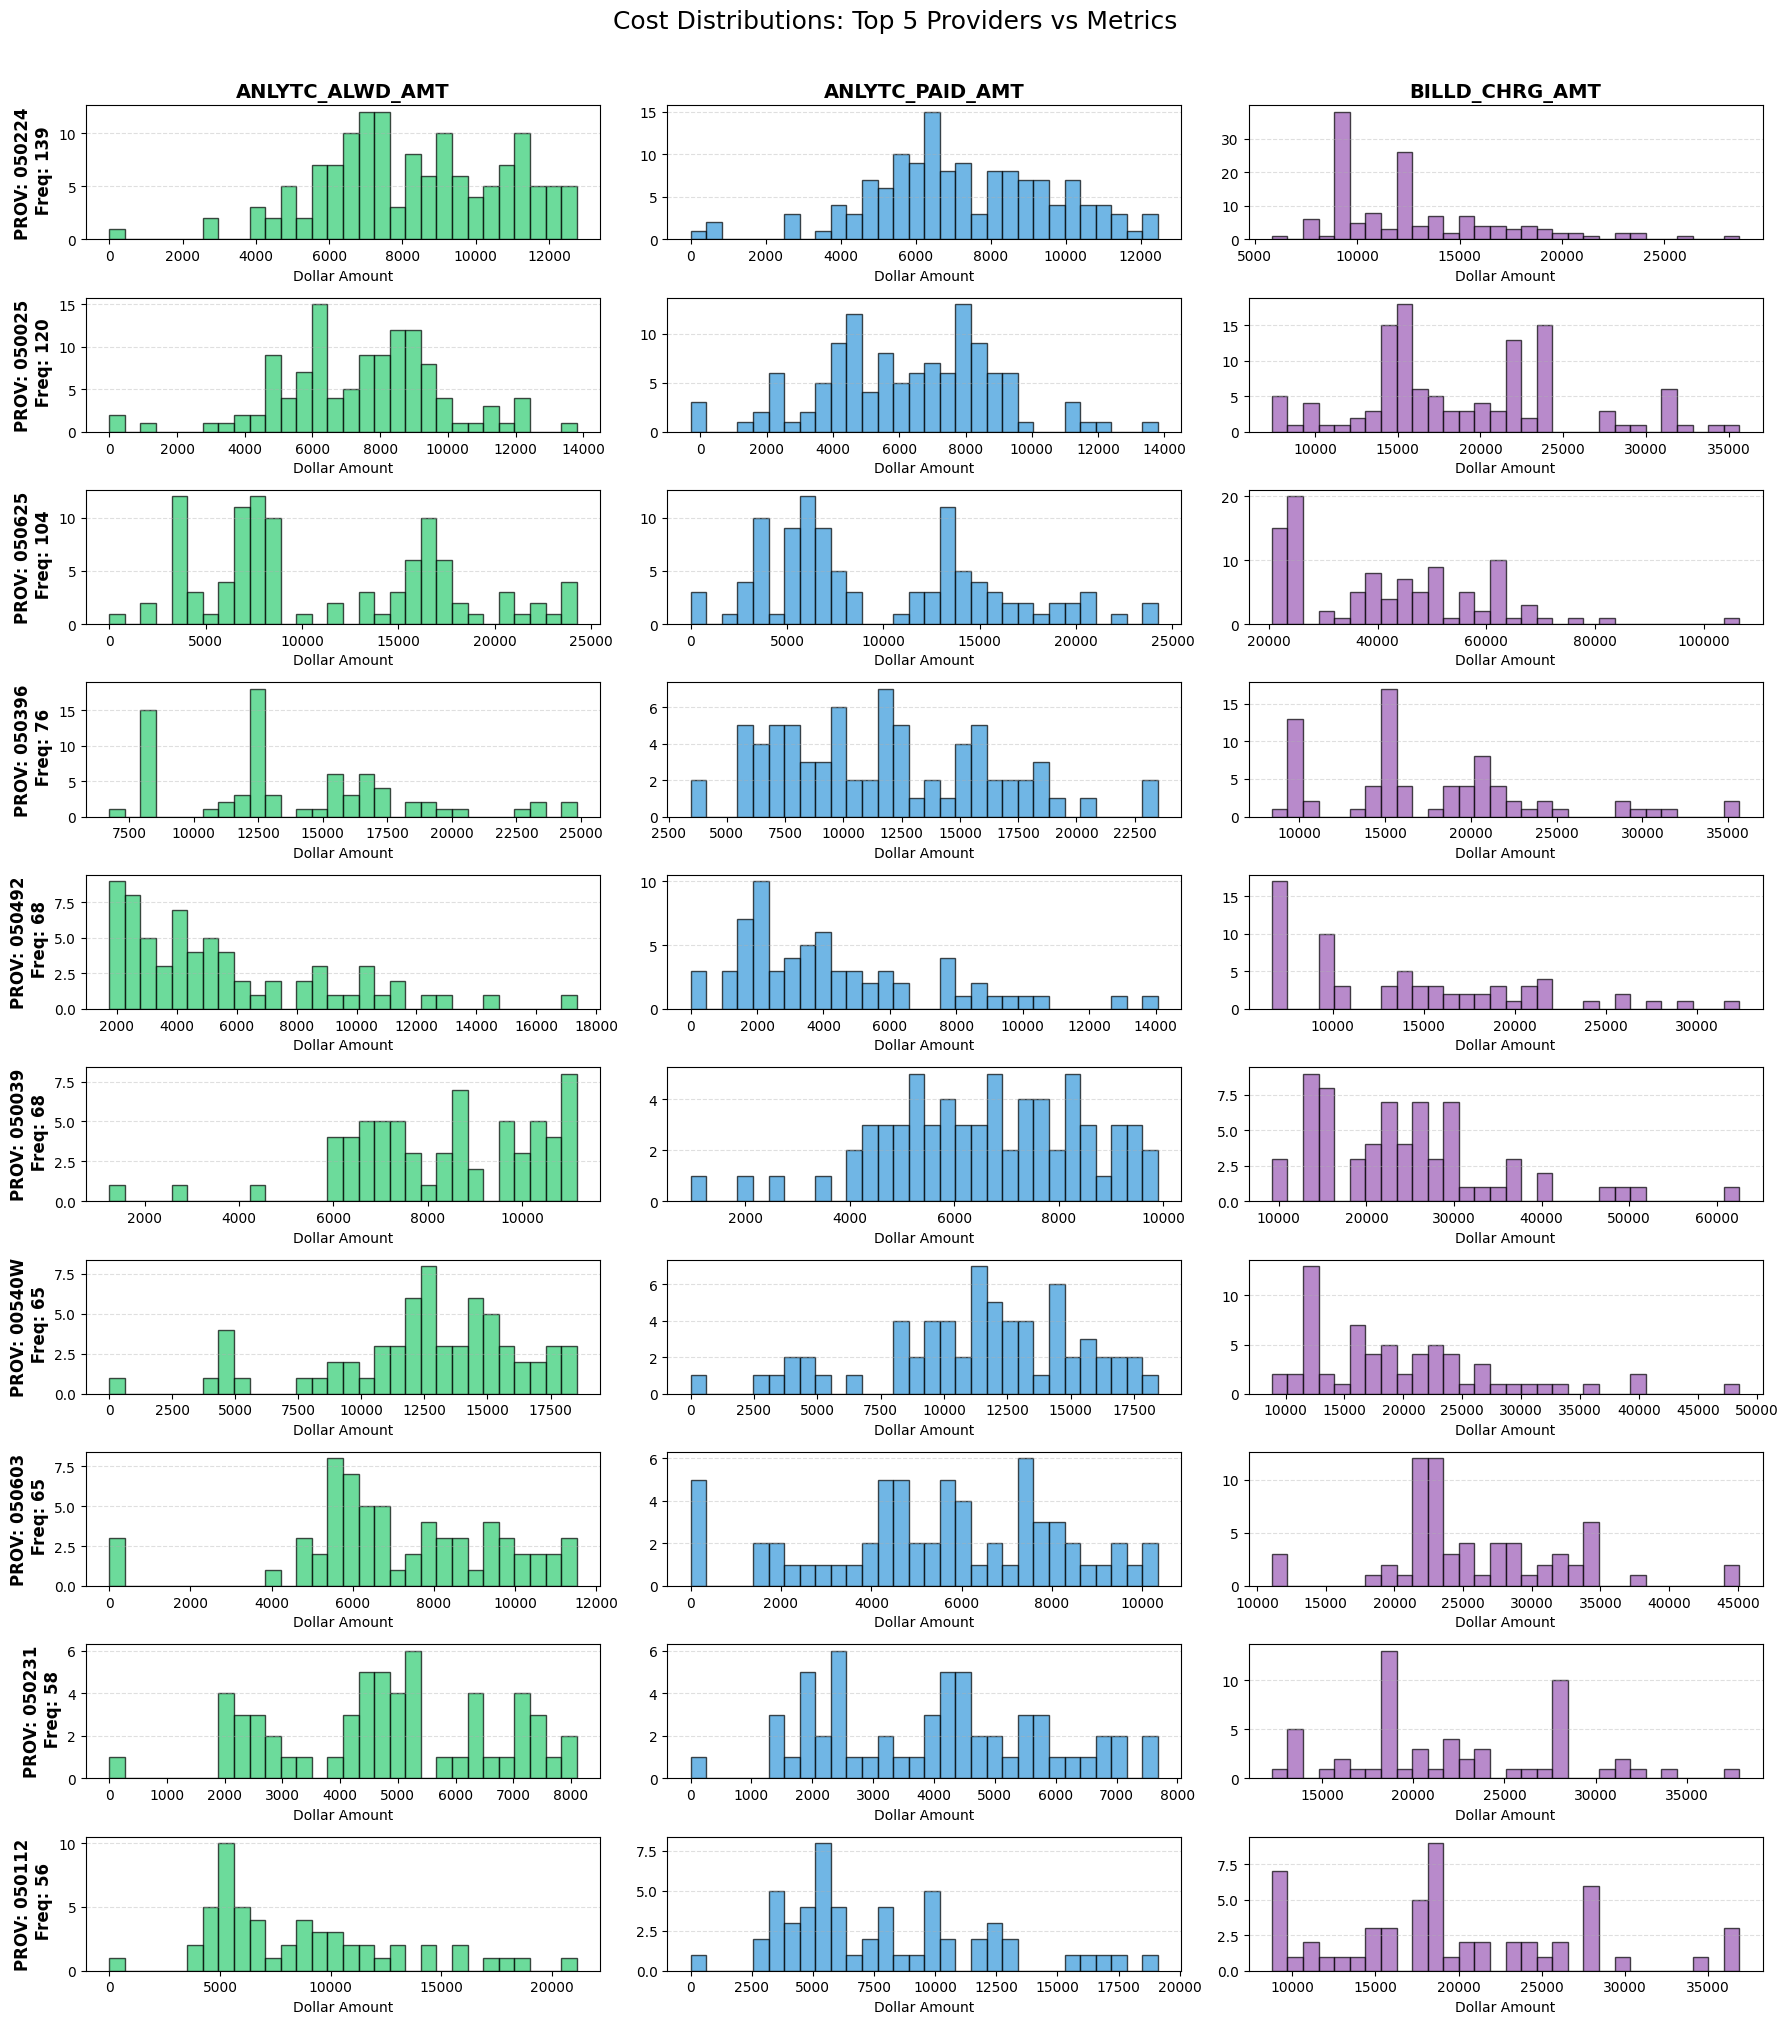

In [ ]:
# 1. Identify the top 5 providers
df2 = df[df['FNL_DRG_CD']==806]
top_prov_ids = df2['PROV_ID'].value_counts().head(5).index.tolist()

metrics = ['ANLYTC_ALWD_AMT', 'ANLYTC_PAID_AMT', 'BILLD_CHRG_AMT']
colors = ['#2ecc71', '#3498db', '#9b59b6'] 

# 2. Setup the figure (5 Rows for Providers, 3 Columns for Metrics)
# Removed sharex='col' so every plot can be labeled independently
fig, axes = plt.subplots(len(top_prov_ids), len(metrics), figsize=(18, 20))

for row_idx, prov_id in enumerate(top_prov_ids):
    for col_idx, metric in enumerate(metrics):
        # Filter for specific Provider and Metric
        subset = df2[df2['PROV_ID'] == prov_id][metric]
        
        # Outlier removal
        upper_limit = subset.quantile(0.99)
        plot_data = subset[subset <= upper_limit]
        
        ax = axes[row_idx, col_idx]
        
        # Plot histogram
        ax.hist(plot_data, bins=30, color=colors[col_idx], edgecolor='black', alpha=0.7)
        
        # X-axis label for every subplot
        ax.set_xlabel('Dollar Amount', fontsize=10)
        
        # Y-axis label (Provider ID) - only on the left-most plots
        if col_idx == 0:
            ax.set_ylabel(f'PROV: {prov_id}\n Freq: {len(df2[df2['PROV_ID'] == prov_id])}', 
                          fontsize=12, fontweight='bold')
        
        # Column Titles (Metrics) - only on the top row
        if row_idx == 0:
            ax.set_title(metric, fontsize=14, fontweight='bold')
            
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Cost Distributions: Top 5 Providers vs Metrics', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()


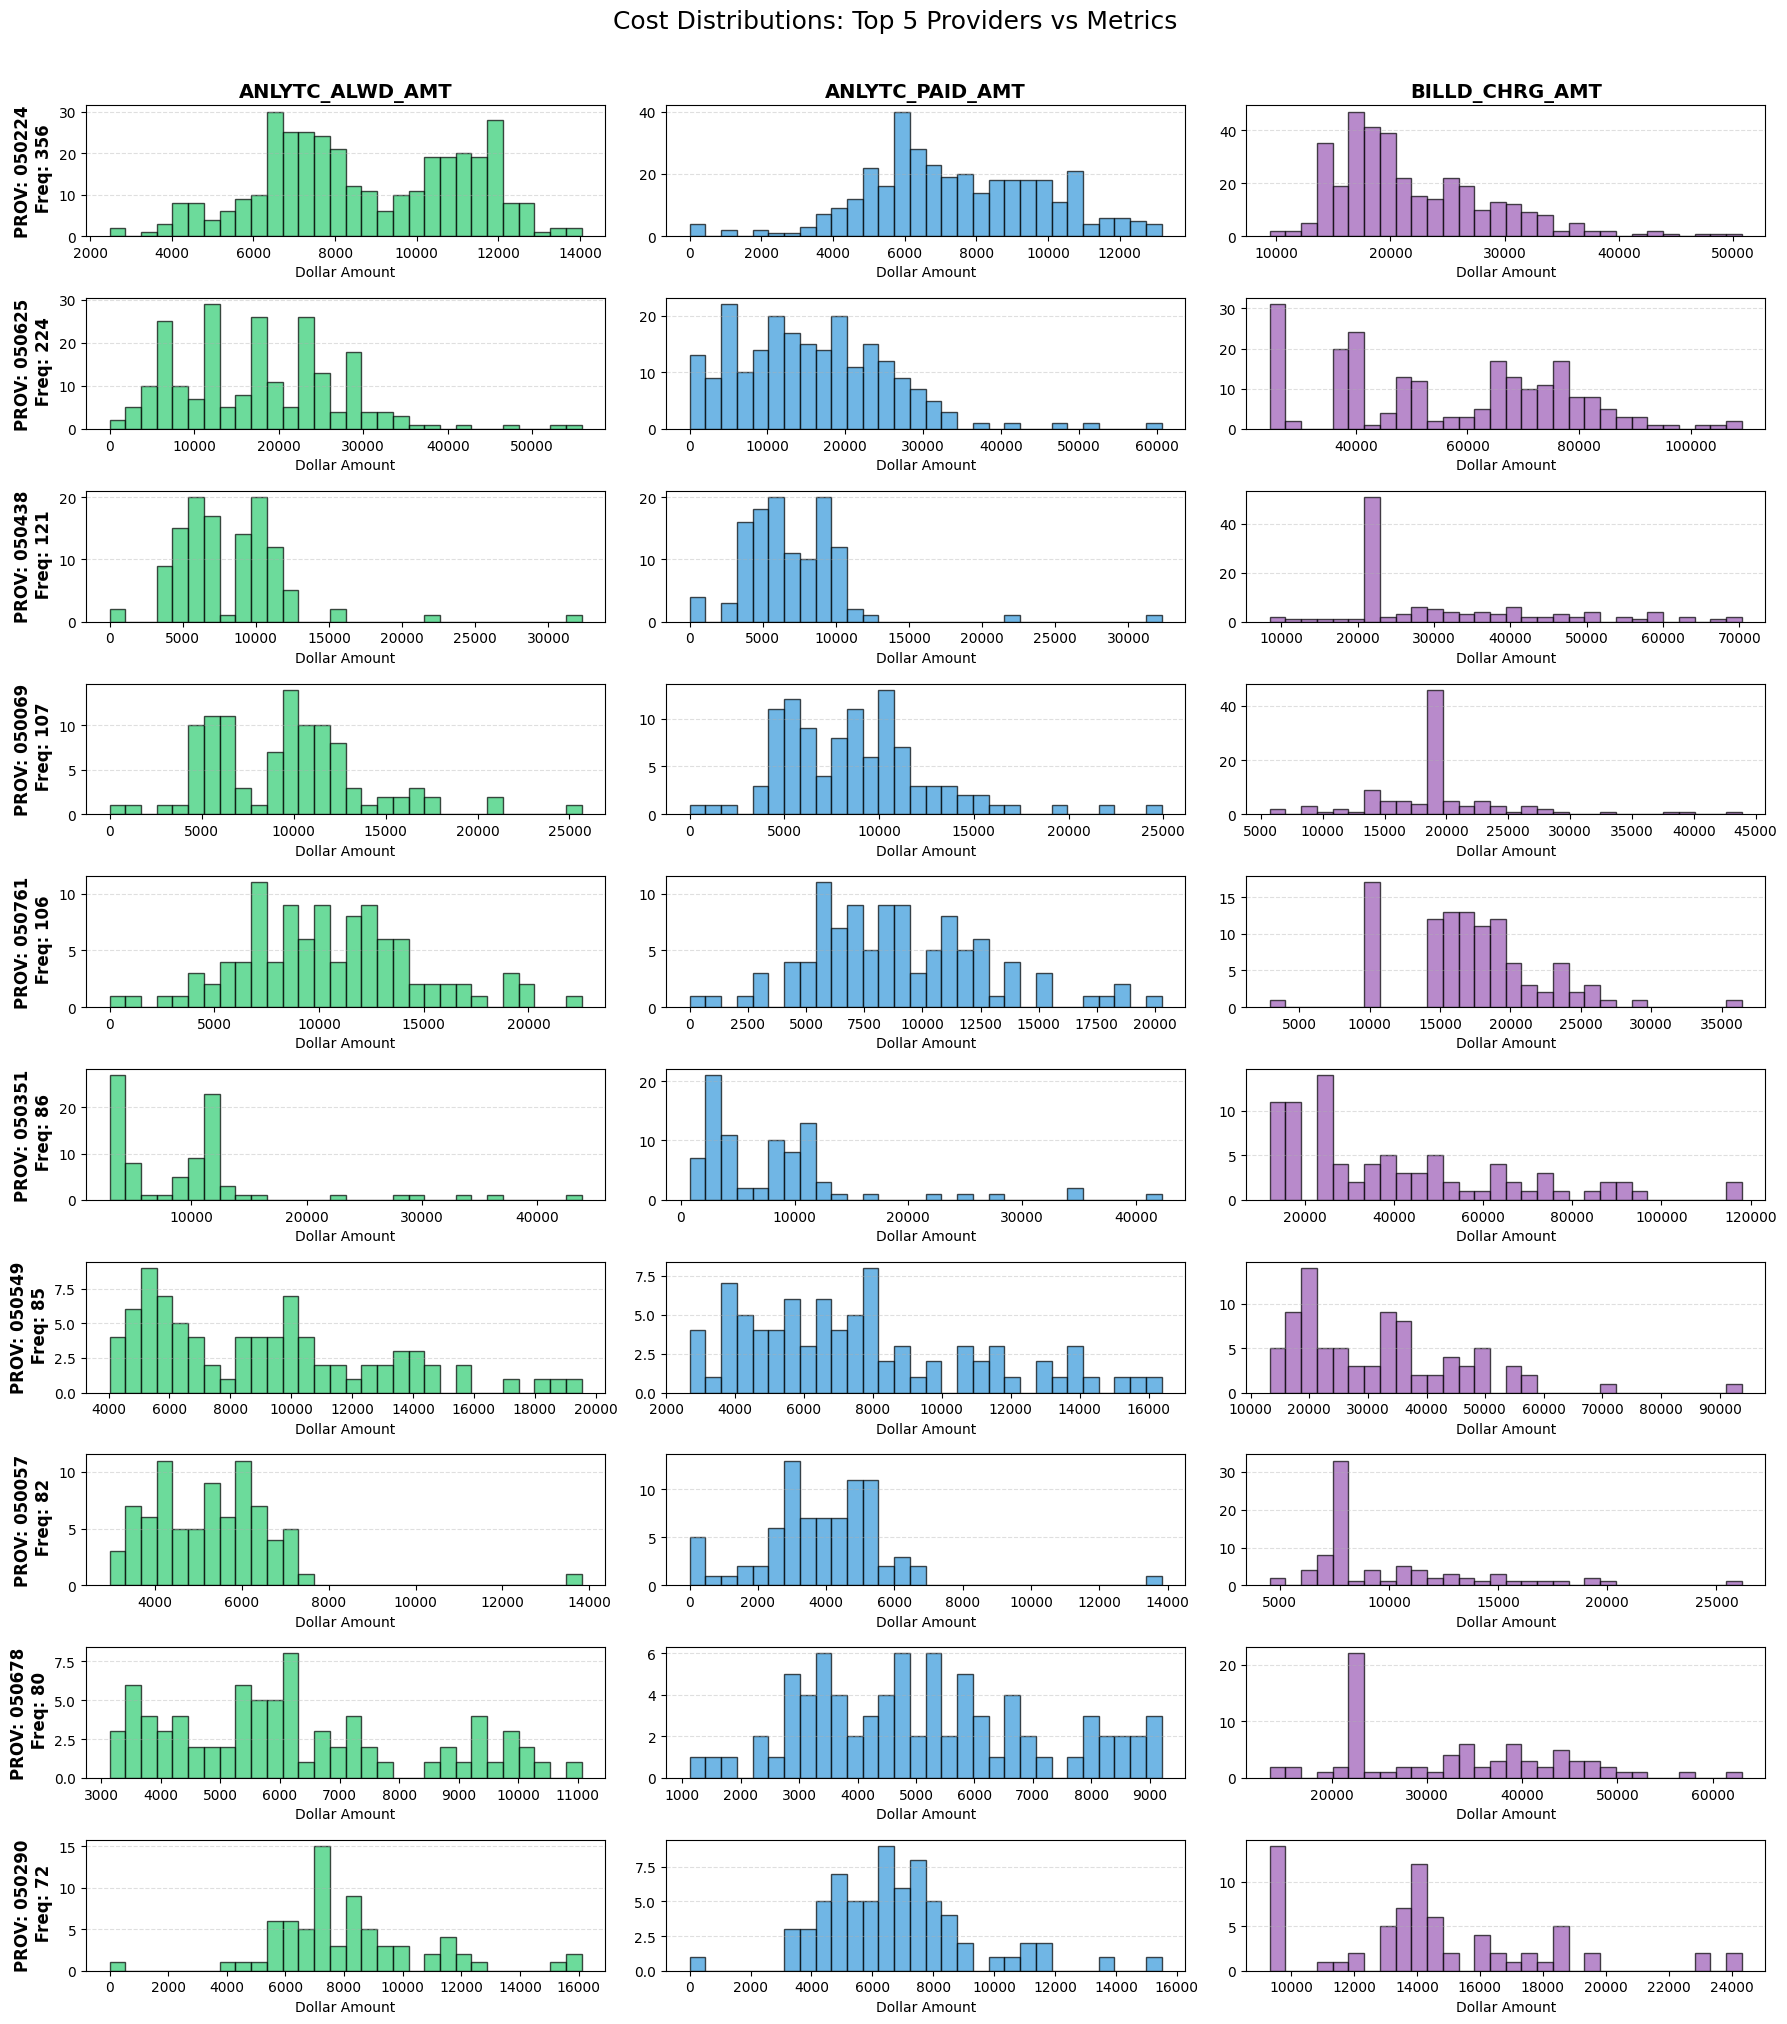

In [ ]:
# 1. Identify the top 5 providers
df2 = df[df['FNL_DRG_CD']==788]
top_prov_ids = df2['PROV_ID'].value_counts().head(5).index.tolist()

metrics = ['ANLYTC_ALWD_AMT', 'ANLYTC_PAID_AMT', 'BILLD_CHRG_AMT']
colors = ['#2ecc71', '#3498db', '#9b59b6'] 

# 2. Setup the figure (5 Rows for Providers, 3 Columns for Metrics)
# Removed sharex='col' so every plot can be labeled independently
fig, axes = plt.subplots(len(top_prov_ids), len(metrics), figsize=(18, 20))

for row_idx, prov_id in enumerate(top_prov_ids):
    for col_idx, metric in enumerate(metrics):
        # Filter for specific Provider and Metric
        subset = df2[df2['PROV_ID'] == prov_id][metric]
        
        # Outlier removal
        upper_limit = subset.quantile(0.99)
        plot_data = subset[subset <= upper_limit]
        
        ax = axes[row_idx, col_idx]
        
        # Plot histogram
        ax.hist(plot_data, bins=30, color=colors[col_idx], edgecolor='black', alpha=0.7)
        
        # X-axis label for every subplot
        ax.set_xlabel('Dollar Amount', fontsize=10)
        
        # Y-axis label (Provider ID) - only on the left-most plots
        if col_idx == 0:
            ax.set_ylabel(f'PROV: {prov_id}\n Freq: {len(df2[df2['PROV_ID'] == prov_id])}', 
                          fontsize=12, fontweight='bold')
        
        # Column Titles (Metrics) - only on the top row
        if row_idx == 0:
            ax.set_title(metric, fontsize=14, fontweight='bold')
            
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Cost Distributions: Top 5 Providers vs Metrics', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()


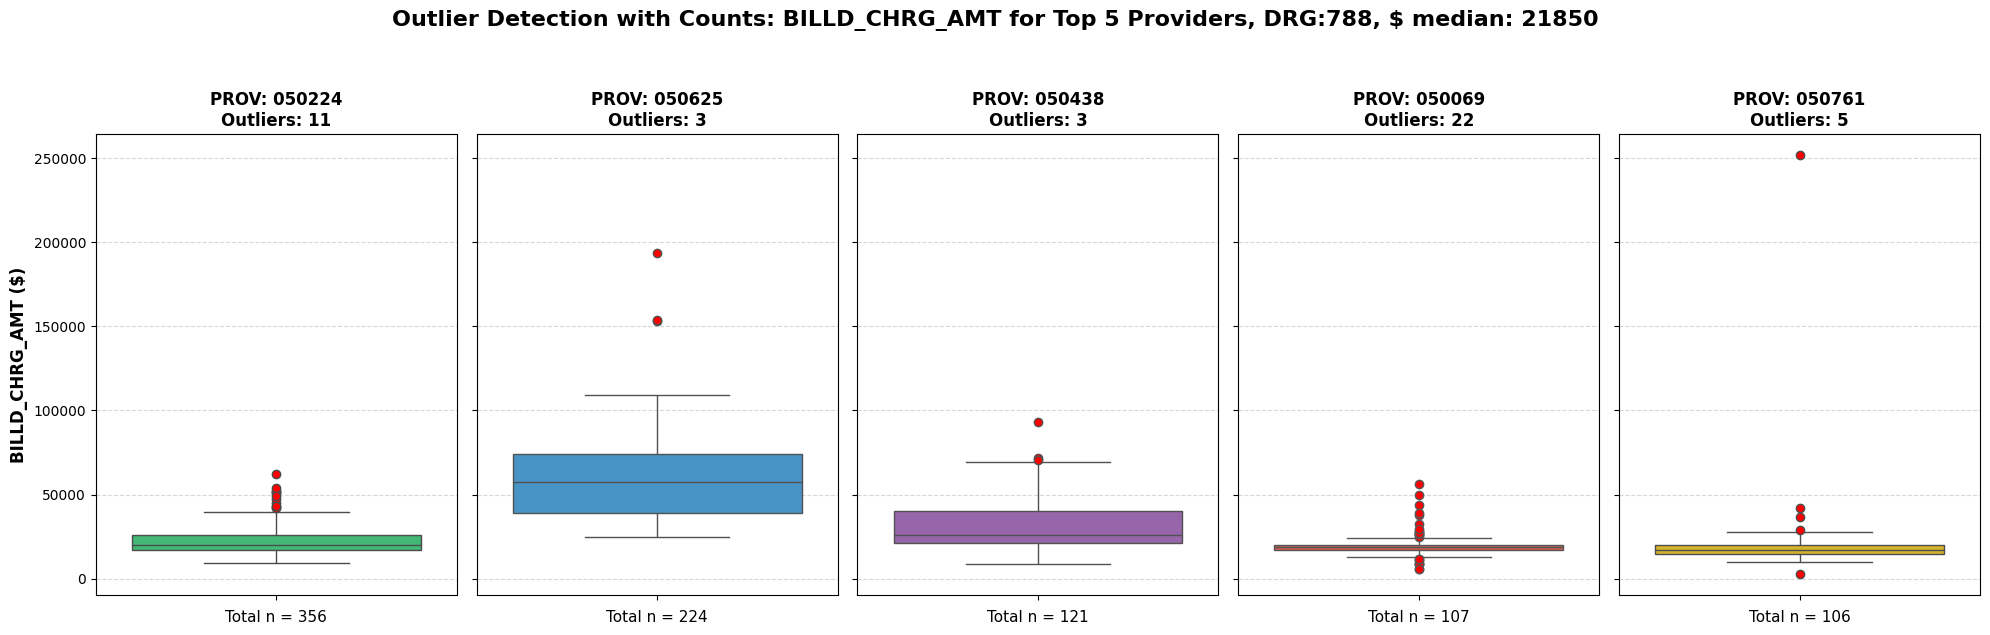

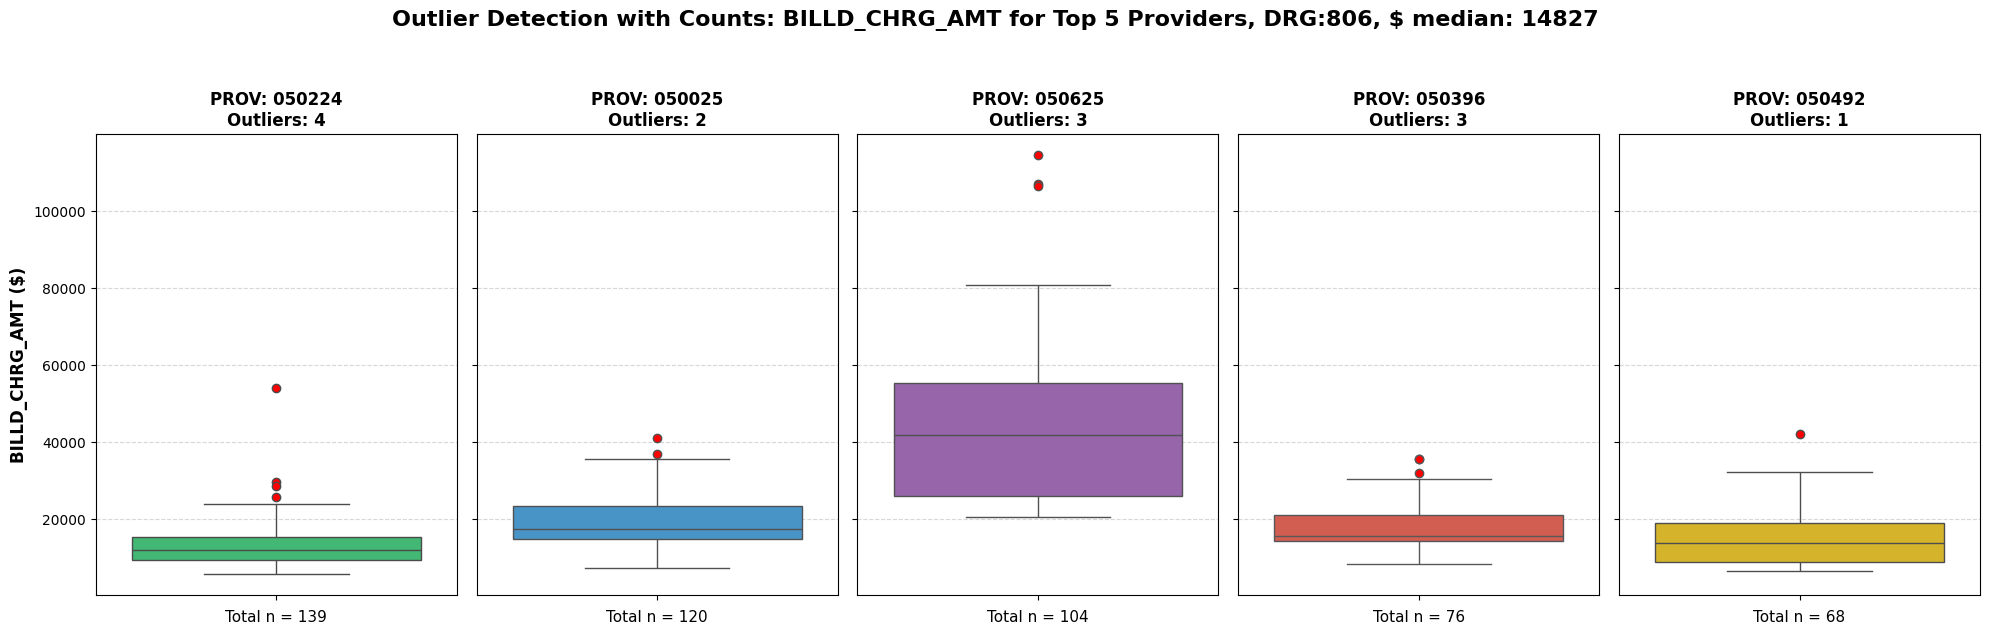

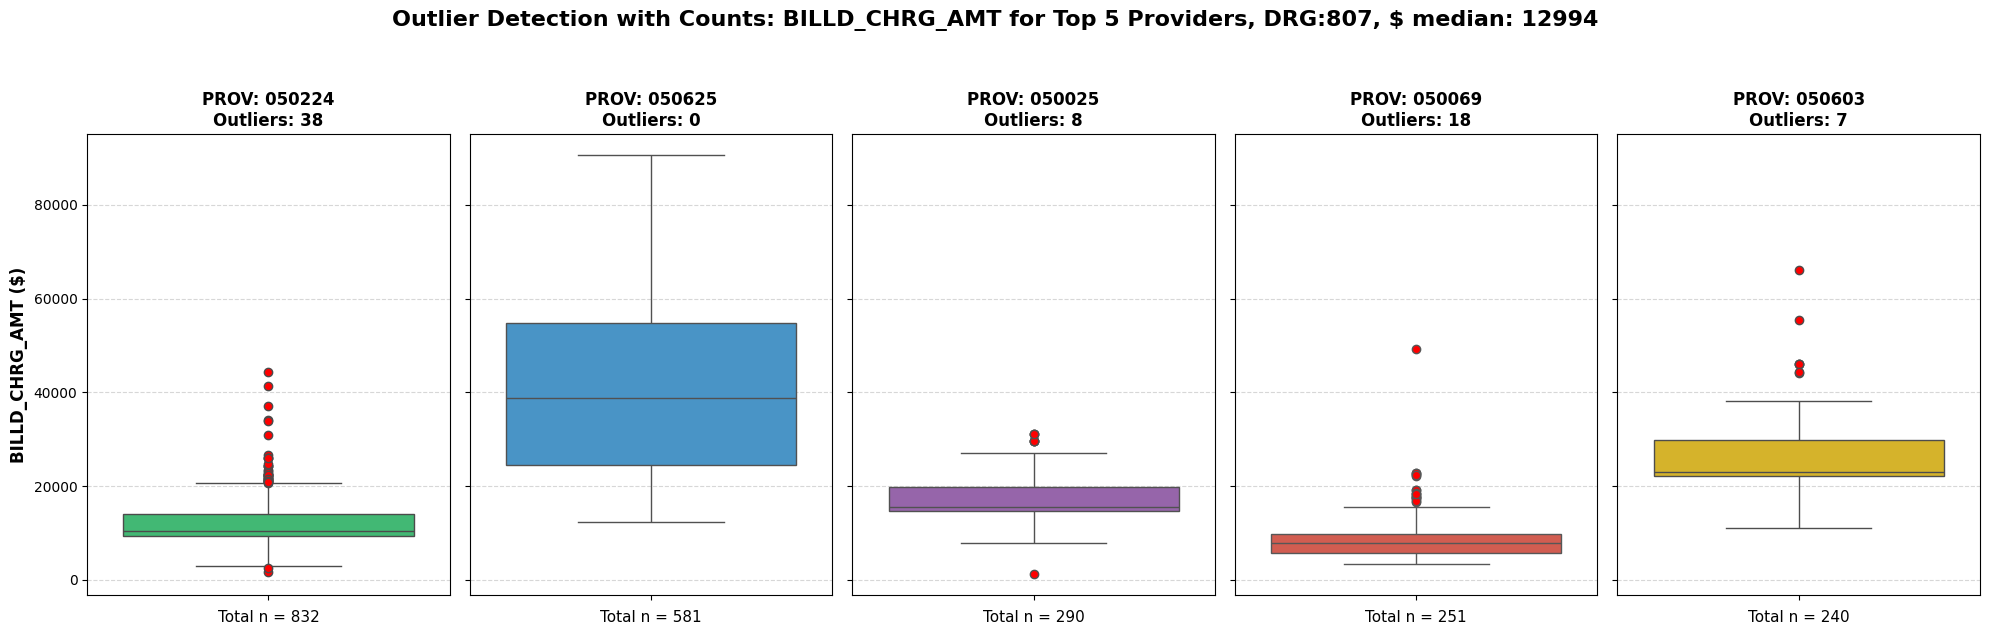

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify top 5 providers
for cd in [788, 806, 807]:
    df2 = df[df['FNL_DRG_CD'] == cd]
    top_prov_ids = df2['PROV_ID'].value_counts().head(5).index.tolist()

    # Filter dataset for only these top 5 providers
    df_top_prov = df2[df2['PROV_ID'].isin(top_prov_ids)]

    # 2. Setup the figure (1 Row, 5 Columns for each Provider)
    fig, axes = plt.subplots(1, len(top_prov_ids), figsize=(20, 6), sharey=True)

    # Define color palette for the 5 providers
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f1c40f']

    for idx, prov_id in enumerate(top_prov_ids):
        ax = axes[idx]
        
        # Extract data for specific provider
        plot_data = df_top_prov[df_top_prov['PROV_ID'] == prov_id]['BILLD_CHRG_AMT'].dropna()
        
        # Calculate IQR Outliers (Standard Boxplot logic)
        q1 = plot_data.quantile(0.25)
        q3 = plot_data.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Count data points outside the bounds
        outlier_count = ((plot_data < lower_bound) | (plot_data > upper_bound)).sum()
        
        # Generate vertical boxplot
        sns.boxplot(
            y=plot_data, 
            ax=ax, 
            color=colors[idx],
            flierprops={"markerfacecolor": "red", "marker": "o", "markersize": 6}
        )
        
        # Subplot styling - Outlier count injected into the title
        ax.set_title(f'PROV: {prov_id}\nOutliers: {outlier_count}', fontsize=12, fontweight='bold')
        ax.set_xlabel(f'Total n = {len(plot_data)}', fontsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Only label the primary Y-axis on the leftmost plot
        if idx == 0:
            ax.set_ylabel('BILLD_CHRG_AMT ($)', fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel('')
    median = int(df[df['FNL_DRG_CD'] == cd]['BILLD_CHRG_AMT'].median().round(0))
    plt.suptitle(f'Outlier Detection with Counts: BILLD_CHRG_AMT for Top 5 Providers, DRG:{cd}, $ median: {median}', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


np.float64(12994.0)

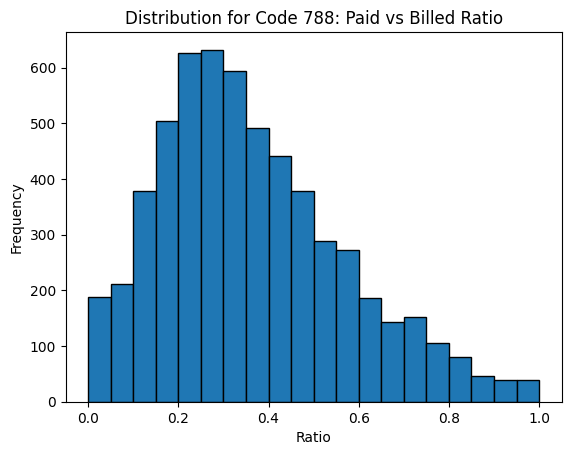

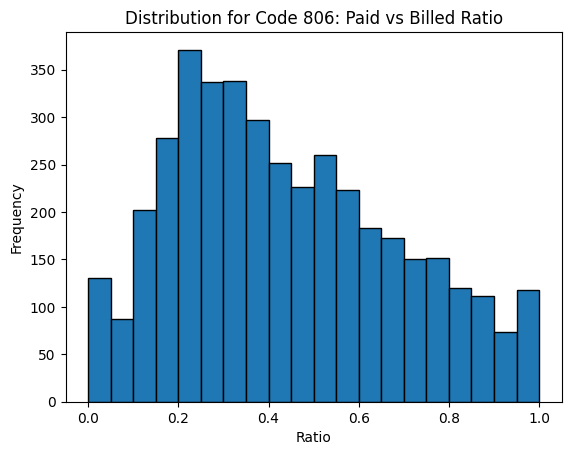

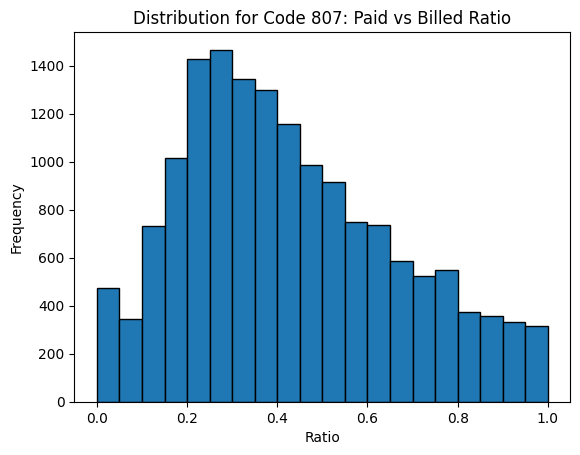

In [ ]:
df['PAID_VS_BILLED'] = df['ANLYTC_PAID_AMT']/ df['BILLD_CHRG_AMT']
for cd in [788, 806, 807]:
    df2 = df[df['FNL_DRG_CD'] == cd]
    
    # Filter data for the ratio plot
    ratio_data = df2[df2['PAID_VS_BILLED'].between(0, 1)]['PAID_VS_BILLED']

    # Initialize a new figure so plots don't overlap
    plt.figure() 
    
    ratio_data.plot(
        kind='hist', 
        bins=20, 
        range=(0, 1), 
        edgecolor='black',
        # Use an f-string to include the 'cd' variable in the title
        title=f'Distribution for Code {cd}: Paid vs Billed Ratio'
    )
    
    plt.xlabel('Ratio')
    plt.ylabel('Frequency')
    plt.show() # Forces the plot to display before moving to the next 'cd'


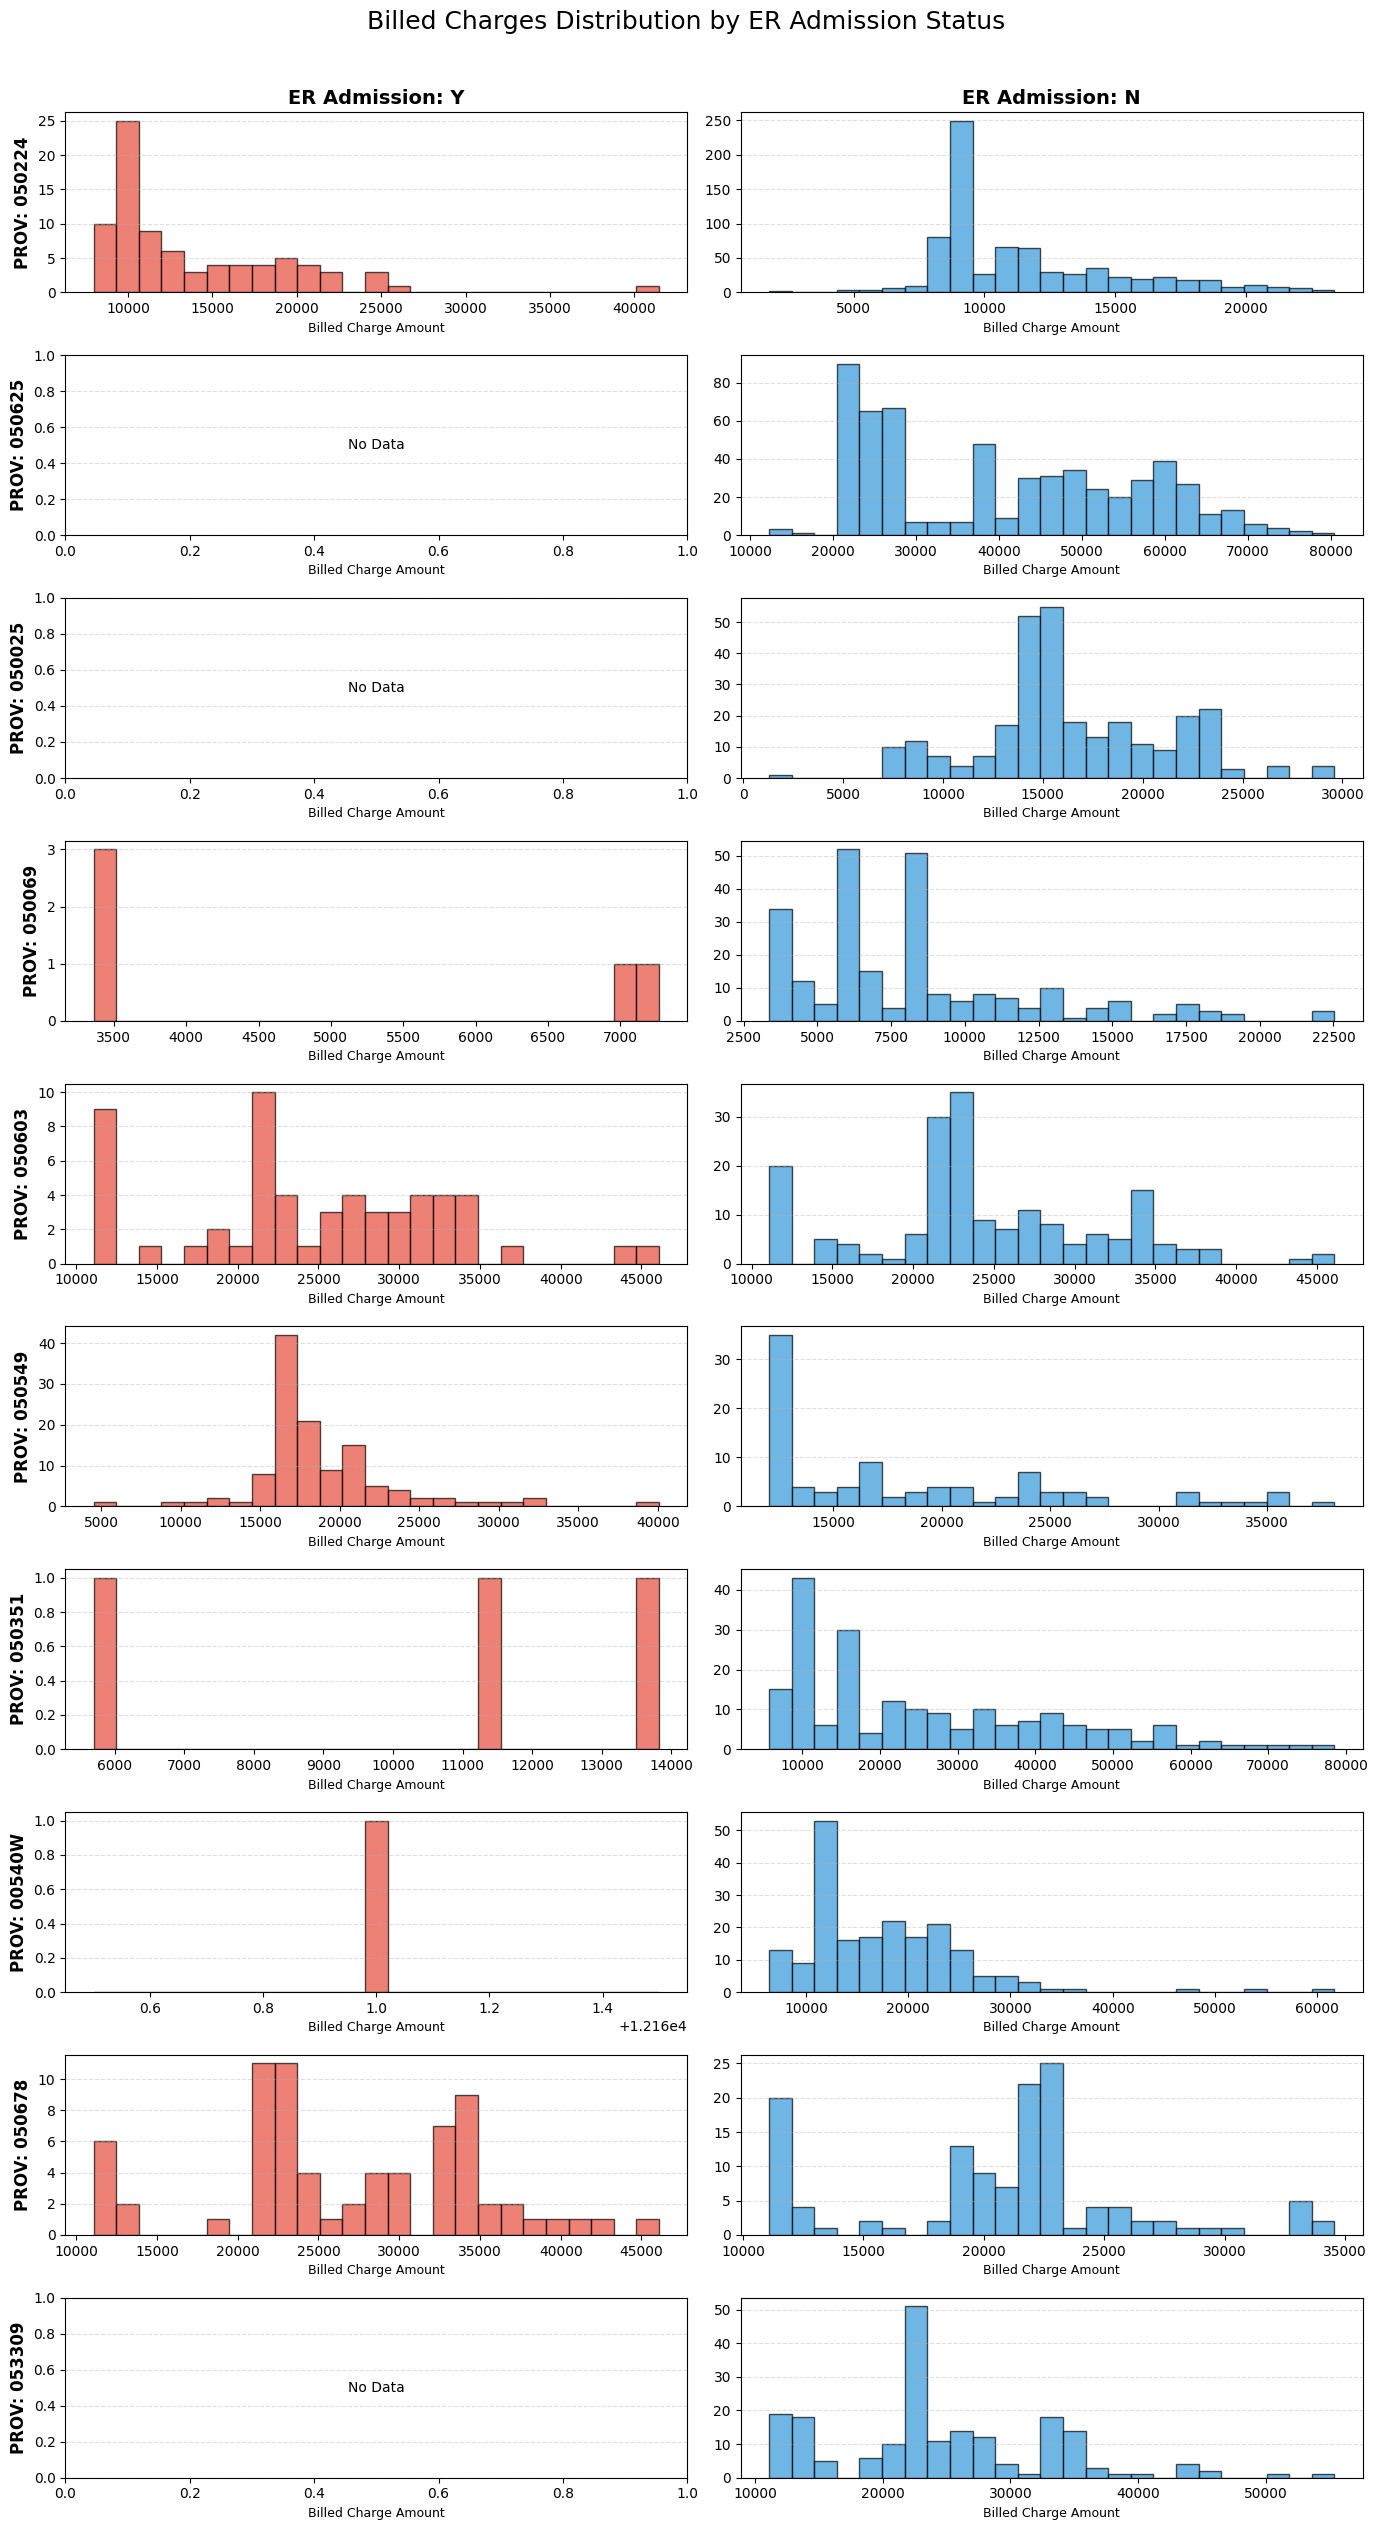

In [ ]:
# 1. Identify the top providers
df2 = df[df['FNL_DRG_CD'] == 807]
top_prov_ids = df2['PROV_ID'].value_counts().head(10).index.tolist()

# Define categories and colors
categories = ['Y', 'N']
colors = {'Y': '#e74c3c', 'N': '#3498db'} 

# 2. Setup the figure (10 Rows for Providers, 2 Columns for ER Admission status)
fig, axes = plt.subplots(len(top_prov_ids), 2, figsize=(14, 25), sharey=False)

for row_idx, prov_id in enumerate(top_prov_ids):
    for col_idx, status in enumerate(categories):
        # Filter for specific Provider, Metric, and ER Admission status
        subset = df2[(df2['PROV_ID'] == prov_id) & (df2['ER_ADMT_IND'] == status)]['BILLD_CHRG_AMT']
        
        ax = axes[row_idx, col_idx]
        
        if not subset.empty:
            # Outlier removal (99th percentile)
            upper_limit = subset.quantile(0.99)
            plot_data = subset[subset <= upper_limit]
            
            # Plot histogram
            ax.hist(plot_data, bins=25, color=colors[status], edgecolor='black', alpha=0.7)
        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center')

        # Formatting labels
        ax.set_xlabel('Billed Charge Amount', fontsize=9)
        
        # Provider ID on the left-most plots
        if col_idx == 0:
            ax.set_ylabel(f'PROV: {prov_id}', fontsize=12, fontweight='bold')
        
        # Category Titles (Y/N) on the top row
        if row_idx == 0:
            ax.set_title(f'ER Admission: {status}', fontsize=14, fontweight='bold')
            
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Billed Charges Distribution by ER Admission Status', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()
